# Entrenamiento y Evaluación de Modelos

Entrena y evalúa modelos de clasificación para predecir el comportamiento de precios (Alza/Estable/Caída).

In [8]:
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report 
)
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [9]:
%run "preprocesamiento.ipynb"

Registros crudos cargados: 30088
Procesando 0/118...
Procesando 25/118...
Procesando 50/118...
Procesando 75/118...
Procesando 100/118...
Registros preprocesados (con umbral ±3%): 21580
Columnas: ['producto', 'provincia', 'periodo', 'precio_actual', 'precio_t1', 'precio_t2', 'variacion_t2_t1', 'distancia_pm2_pct', 'distancia_pm3_pct', 'año', 'mes', 'quincena', 'variacion_real', 'comportamiento', 'categoria', 'producto_encoded', 'provincia_encoded', 'categoria_perecedero']

Distribución de comportamiento:
comportamiento
Estable    12033
Alza        4833
Caída       4714
Name: count, dtype: int64

✅ Guardado en: data/processed/dataset_preprocesado_sipa.csv
Productos únicos crudos: 1254
Después de normalizar (reglas): 322
Después de agrupar por similitud: 86
Después de agrupar (respetando presentación): 225
producto_v3
Tomate Rinon de Invernadero (Gaveta aprox. 40 lb)     184
Tomate Rinon de Invernadero (Carton aprox. 55 lb)     181
Tomate Rinon de Invernadero (Caja aprox. 40 lb)       12

## Carga del dataset preprocesado

In [10]:
df_crudo = pd.read_csv('data/processed/dataset_crudo_sipa.csv')
resultado_preproc = preprocesar_datos(df_crudo)
df = resultado_preproc['dataset_final']

print(f"Registros: {len(df)}")
print(df.columns.tolist())

Procesando 0/118...
Procesando 25/118...
Procesando 50/118...
Procesando 75/118...
Procesando 100/118...
Registros: 21580
['producto', 'provincia', 'periodo', 'precio_actual', 'precio_t1', 'precio_t2', 'variacion_t2_t1', 'distancia_pm2_pct', 'distancia_pm3_pct', 'año', 'mes', 'quincena', 'variacion_real', 'comportamiento', 'categoria', 'producto_encoded', 'provincia_encoded', 'categoria_perecedero']


In [11]:
for col in df.columns:
    print(col)

producto
provincia
periodo
precio_actual
precio_t1
precio_t2
variacion_t2_t1
distancia_pm2_pct
distancia_pm3_pct
año
mes
quincena
variacion_real
comportamiento
categoria
producto_encoded
provincia_encoded
categoria_perecedero


## Paso 1 — Limpieza de filas sin historia suficiente (NaN por rezago)


In [12]:
features_rezago = ['precio_t2', 'variacion_t2_t1', 'distancia_pm2_pct', 'distancia_pm3_pct']

print('Filas con NaN en features de rezago:')
for col in features_rezago:
    n_nan = df[col].isna().sum()
    print(f'  {col}: {n_nan} NaN ({n_nan/len(df)*100:.1f}%)')

filas_antes = len(df)
df_limpio = df.dropna(subset=features_rezago).copy()
filas_despues = len(df_limpio)
filas_eliminadas = filas_antes - filas_despues

print(f'\n--- Resumen limpieza ---')
print(f'Filas antes:        {filas_antes}')
print(f'Filas eliminadas:   {filas_eliminadas} ({filas_eliminadas/filas_antes*100:.1f}%)')
print(f'Filas disponibles:  {filas_despues}')
print(f'\nDistribución después de limpieza:')
print(df_limpio['comportamiento'].value_counts())

Filas con NaN en features de rezago:
  precio_t2: 118 NaN (0.5%)
  variacion_t2_t1: 118 NaN (0.5%)
  distancia_pm2_pct: 118 NaN (0.5%)
  distancia_pm3_pct: 236 NaN (1.1%)

--- Resumen limpieza ---
Filas antes:        21580
Filas eliminadas:   236 (1.1%)
Filas disponibles:  21344

Distribución después de limpieza:
comportamiento
Estable    11923
Alza        4780
Caída       4641
Name: count, dtype: int64


## Paso 2 — Variables predictoras y target

In [13]:
FEATURES = [
    'precio_t1', 'precio_t2', 'variacion_t2_t1',
    'distancia_pm2_pct', 'distancia_pm3_pct',
    'mes', 'producto_encoded', 'provincia_encoded', 'categoria_perecedero'
]
TARGET = 'comportamiento'

X = df_limpio[FEATURES].copy()
y = df_limpio[TARGET].copy()

# Codificar target a numérico para XGBoost
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)
print(f'Mapeo target: {dict(zip(le_target.classes_, range(len(le_target.classes_))))}')
print(f'Features shape: {X.shape}')
print(f'Target shape: {y_encoded.shape}')
print(f'\nNaN restantes en X:')
print(X.isna().sum())

Mapeo target: {'Alza': 0, 'Caída': 1, 'Estable': 2}
Features shape: (21344, 9)
Target shape: (21344,)

NaN restantes en X:
precio_t1               0
precio_t2               0
variacion_t2_t1         0
distancia_pm2_pct       0
distancia_pm3_pct       0
mes                     0
producto_encoded        0
provincia_encoded       0
categoria_perecedero    0
dtype: int64


## Paso 3 — División temporal (TimeSeriesSplit)

Los datos son series de tiempo: no se puede usar shuffle aleatorio. Se usa `TimeSeriesSplit` con 5 splits.

In [14]:
tscv = TimeSeriesSplit(n_splits=5)

print('Divisiones temporales:')
for i, (train_idx, test_idx) in enumerate(tscv.split(X)):
    print(f'  Fold {i+1}: train={len(train_idx)} filas, test={len(test_idx)} filas')
    print(f'           train periodos: {df_limpio.iloc[train_idx]["periodo"].min()} -> {df_limpio.iloc[train_idx]["periodo"].max()}')
    print(f'           test  periodos: {df_limpio.iloc[test_idx]["periodo"].min()} -> {df_limpio.iloc[test_idx]["periodo"].max()}')

Divisiones temporales:
  Fold 1: train=3559 filas, test=3557 filas
           train periodos: 2018-12-Q2 -> 2026-07-Q1
           test  periodos: 2018-12-Q2 -> 2026-07-Q1
  Fold 2: train=7116 filas, test=3557 filas
           train periodos: 2018-12-Q2 -> 2026-07-Q1
           test  periodos: 2018-12-Q2 -> 2026-07-Q1
  Fold 3: train=10673 filas, test=3557 filas
           train periodos: 2018-12-Q2 -> 2026-07-Q1
           test  periodos: 2018-12-Q2 -> 2026-07-Q1
  Fold 4: train=14230 filas, test=3557 filas
           train periodos: 2018-12-Q2 -> 2026-07-Q1
           test  periodos: 2018-12-Q2 -> 2026-07-Q1
  Fold 5: train=17787 filas, test=3557 filas
           train periodos: 2018-12-Q2 -> 2026-07-Q1
           test  periodos: 2018-12-Q2 -> 2026-07-Q1


In [15]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

# Usa la misma X, y_encoded que ya tienes definidas (9 features, 15985 filas)
tscv = TimeSeriesSplit(n_splits=5)

# Grid de hiperparámetros a probar (ajusta si quieres más/menos combinaciones)
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_child_weight': [1, 5, 10],   # controla sobreajuste con pocos datos por hoja
    'subsample': [0.7, 1.0],          # ayuda a que no memorice ruido de OCR
}

# Pesos de clase balanceados (igual que ya venían usando)
pesos_completos = compute_sample_weight('balanced', y_encoded)

xgb_base = XGBClassifier(
    tree_method='hist',
    random_state=42,
    eval_metric='mlogloss',
    n_jobs=-1
)

print("Iniciando GridSearchCV... esto puede tardar varios minutos (72 combinaciones x 5 folds = 360 entrenamientos).")

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=tscv,
    scoring='f1_macro',   # optimiza directamente para el criterio que exige el proyecto
    n_jobs=-1,
    verbose=2,
)

grid_search.fit(X, y_encoded, sample_weight=pesos_completos)

print("\n=== MEJORES HIPERPARÁMETROS ENCONTRADOS ===")
print(grid_search.best_params_)
print(f"\nMejor F1-Score (Macro) promedio en validación: {grid_search.best_score_:.4f}")

# Evaluar el mejor modelo con las métricas completas de siempre (accuracy, precision, recall)
mejor_xgb = grid_search.best_estimator_

fold_metrics = []
for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

    pesos_train = compute_sample_weight('balanced', y_train)
    modelo_fold = type(mejor_xgb)(**mejor_xgb.get_params())
    modelo_fold.fit(X_train, y_train, sample_weight=pesos_train)
    y_pred = modelo_fold.predict(X_test)

    from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
    fold_metrics.append({
        'accuracy': accuracy_score(y_test, y_pred),
        'f1_macro': f1_score(y_test, y_pred, average='macro'),
        'precision': precision_score(y_test, y_pred, average='macro'),
        'recall': recall_score(y_test, y_pred, average='macro'),
    })

resumen = pd.DataFrame(fold_metrics).mean()
print("\n=== XGBoost OPTIMIZADO — PROMEDIO 5 FOLDS ===")
print(resumen.round(4))
print(f"\n¿Cumple criterios? F1>=0.75: {resumen['f1_macro']>=0.75} | Acc>=0.80: {resumen['accuracy']>=0.80}")

Iniciando GridSearchCV... esto puede tardar varios minutos (72 combinaciones x 5 folds = 360 entrenamientos).
Fitting 5 folds for each of 216 candidates, totalling 1080 fits



=== MEJORES HIPERPARÁMETROS ENCONTRADOS ===
{'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 10, 'n_estimators': 100, 'subsample': 0.7}

Mejor F1-Score (Macro) promedio en validación: 0.4946

=== XGBoost OPTIMIZADO — PROMEDIO 5 FOLDS ===
accuracy     0.4949
f1_macro     0.4516
precision    0.5166
recall       0.4976
dtype: float64

¿Cumple criterios? F1>=0.75: False | Acc>=0.80: False


## Paso 4 — Entrenamiento de los 6 modelos

Se entrenan los 6 modelos bajo las mismas condiciones (mismas features, mismo split temporal).

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight

MODELOS_QUE_NECESITAN_ESCALADO = {"Logistic Regression", "SVM"}

print("Columnas en X:", X.columns.tolist())
print("Shape de X:", X.shape)
print(X.head(3))

modelos_config = {
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1, class_weight='balanced'),
    'XGBoost': XGBClassifier(learning_rate=0.05, max_depth=10, n_estimators=200, tree_method='hist', random_state=42, eval_metric='mlogloss', n_jobs=-1),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, min_samples_split=5, random_state=42, class_weight='balanced'),
    'Logistic Regression': LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=42, class_weight='balanced'),
    'KNN': KNeighborsClassifier(n_neighbors=5, weights='distance'),
    'SVM': SVC(C=1.0, kernel='rbf', random_state=42, class_weight='balanced', probability=True),
}

resultados = {}

for nombre, modelo_base in modelos_config.items():
    print(f'\n{"="*50}')
    print(f'  {nombre}')
    print(f'{"="*50}')

    fold_metrics = []
    fold_matrices = []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

        # --- Escalado solo para modelos sensibles a la magnitud (LR, SVM) ---
        if nombre in MODELOS_QUE_NECESITAN_ESCALADO:
            scaler = StandardScaler()
            X_train_fit = scaler.fit_transform(X_train)
            X_test_fit = scaler.transform(X_test)
        else:
            X_train_fit = X_train
            X_test_fit = X_test

        modelo = type(modelo_base)(**modelo_base.get_params())

        if nombre == 'XGBoost':
            pesos_train = compute_sample_weight('balanced', y_train)
            modelo.fit(X_train_fit, y_train, sample_weight=pesos_train)
        else:
            modelo.fit(X_train_fit, y_train)

        y_pred = modelo.predict(X_test_fit)

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='macro')
        prec = precision_score(y_test, y_pred, average='macro')
        rec = recall_score(y_test, y_pred, average='macro')
        cm = confusion_matrix(y_test, y_pred)

        fold_metrics.append({'accuracy': acc, 'f1_macro': f1, 'precision': prec, 'recall': rec})
        fold_matrices.append(cm)

        print(f'  Fold {fold+1}: acc={acc:.4f} | f1={f1:.4f} | prec={prec:.4f} | rec={rec:.4f}')

    metrics_df = pd.DataFrame(fold_metrics)
    promedios = metrics_df.mean().to_dict()
    cm_ultimo = fold_matrices[-1]

    resultados[nombre] = {
        'metricas': promedios,
        'metricas_por_fold': metrics_df,
        'matriz_confusion': cm_ultimo,
        'modelo_entrenado': modelo,
        'feature_importances': modelo.feature_importances_ if hasattr(modelo, 'feature_importances_') else None,
    }

    print(f'\n  PROMEDIO: acc={promedios["accuracy"]:.4f} | f1={promedios["f1_macro"]:.4f} | prec={promedios["precision"]:.4f} | rec={promedios["recall"]:.4f}')

Columnas en X: ['precio_t1', 'precio_t2', 'variacion_t2_t1', 'distancia_pm2_pct', 'distancia_pm3_pct', 'mes', 'producto_encoded', 'provincia_encoded', 'categoria_perecedero']
Shape de X: (21344, 9)
   precio_t1  precio_t2  variacion_t2_t1  distancia_pm2_pct  \
2      26.50       26.5             0.00               0.00   
3      26.50       26.5             0.00               0.00   
4      26.25       26.5            -0.94              -0.47   

   distancia_pm3_pct  mes  producto_encoded  provincia_encoded  \
2               0.00   12                 0                  0   
3               0.00    1                 0                  0   
4              -0.63    1                 0                  0   

   categoria_perecedero  
2                     0  
3                     0  
4                     0  

  Random Forest
  Fold 1: acc=0.3807 | f1=0.3617 | prec=0.4807 | rec=0.4290
  Fold 2: acc=0.5727 | f1=0.5004 | prec=0.5041 | rec=0.5274
  Fold 3: acc=0.4757 | f1=0.4538 | prec=0.4

## Paso 5 — Evaluación y métricas comparativas

In [17]:
# Tabla comparativa
tabla = pd.DataFrame({
    nombre: res['metricas'] for nombre, res in resultados.items()
}).T
tabla = tabla[['accuracy', 'f1_macro', 'precision', 'recall']]
tabla.columns = ['Accuracy', 'F1-Score (Macro)', 'Precision (Macro)', 'Recall (Macro)']
tabla = tabla.round(4)

print('=== TABLA COMPARATIVA DE MODELOS ===\n')
print(tabla.to_string())
print(f'\nCriterios de selección: F1-Score >= 0.75 AND Accuracy >= 0.80')

for nombre, res in resultados.items():
    cumple_f1 = res['metricas']['f1_macro'] >= 0.75
    cumple_acc = res['metricas']['accuracy'] >= 0.80
    estado = 'CUMPLE' if (cumple_f1 and cumple_acc) else 'NO CUMPLE'
    print(f'  {nombre}: {estado} (F1={res["metricas"]["f1_macro"]:.4f}, Acc={res["metricas"]["accuracy"]:.4f})')

=== TABLA COMPARATIVA DE MODELOS ===

                     Accuracy  F1-Score (Macro)  Precision (Macro)  Recall (Macro)
Random Forest          0.4770            0.4451             0.4934          0.4829
XGBoost                0.4482            0.4097             0.4492          0.4350
Decision Tree          0.4940            0.4630             0.4952          0.4914
Logistic Regression    0.4444            0.4097             0.4815          0.4646
KNN                    0.3974            0.3464             0.3783          0.3679
SVM                    0.3962            0.3736             0.4777          0.4446

Criterios de selección: F1-Score >= 0.75 AND Accuracy >= 0.80
  Random Forest: NO CUMPLE (F1=0.4451, Acc=0.4770)
  XGBoost: NO CUMPLE (F1=0.4097, Acc=0.4482)
  Decision Tree: NO CUMPLE (F1=0.4630, Acc=0.4940)
  Logistic Regression: NO CUMPLE (F1=0.4097, Acc=0.4444)
  KNN: NO CUMPLE (F1=0.3464, Acc=0.3974)
  SVM: NO CUMPLE (F1=0.3736, Acc=0.3962)


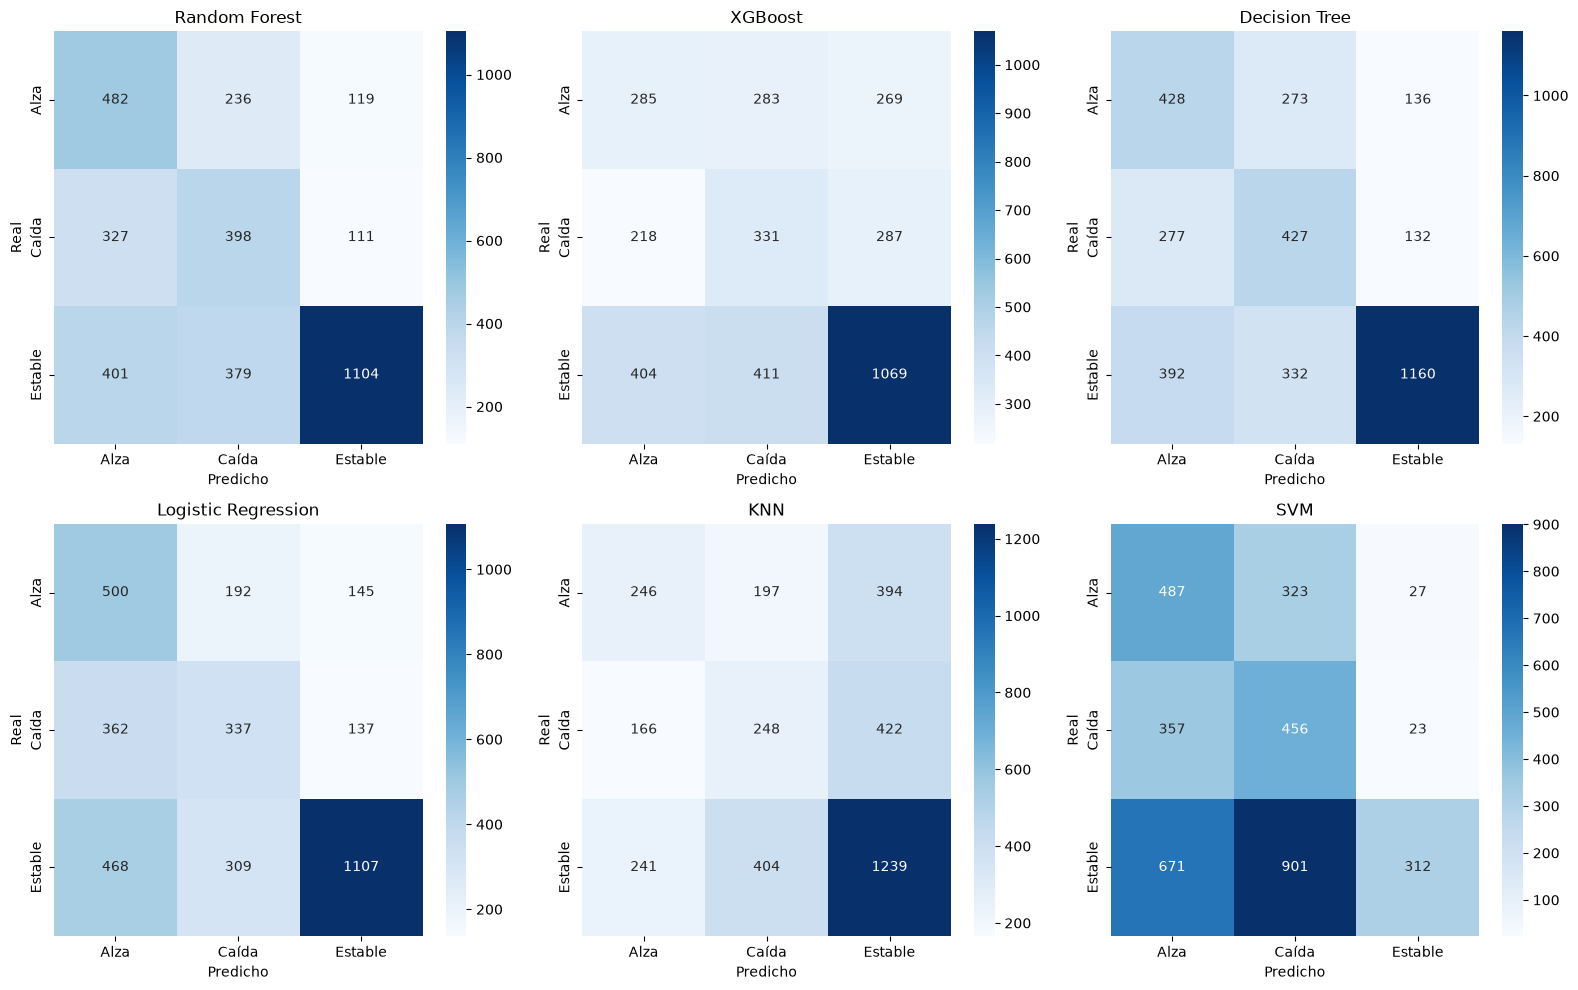

In [18]:
# Matrices de confusión
n_modelos = len(resultados)
n_cols = 3
n_rows = (n_modelos + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten() if n_modelos > 1 else [axes]

for idx, (nombre, res) in enumerate(resultados.items()):
    cm = res['matriz_confusion']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=le_target.classes_, yticklabels=le_target.classes_)
    axes[idx].set_title(f'{nombre}')
    axes[idx].set_xlabel('Predicho')
    axes[idx].set_ylabel('Real')

# Ocultar ejes vacíos
for idx in range(n_modelos, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

## Paso 7 — Análisis: Importancia de variables

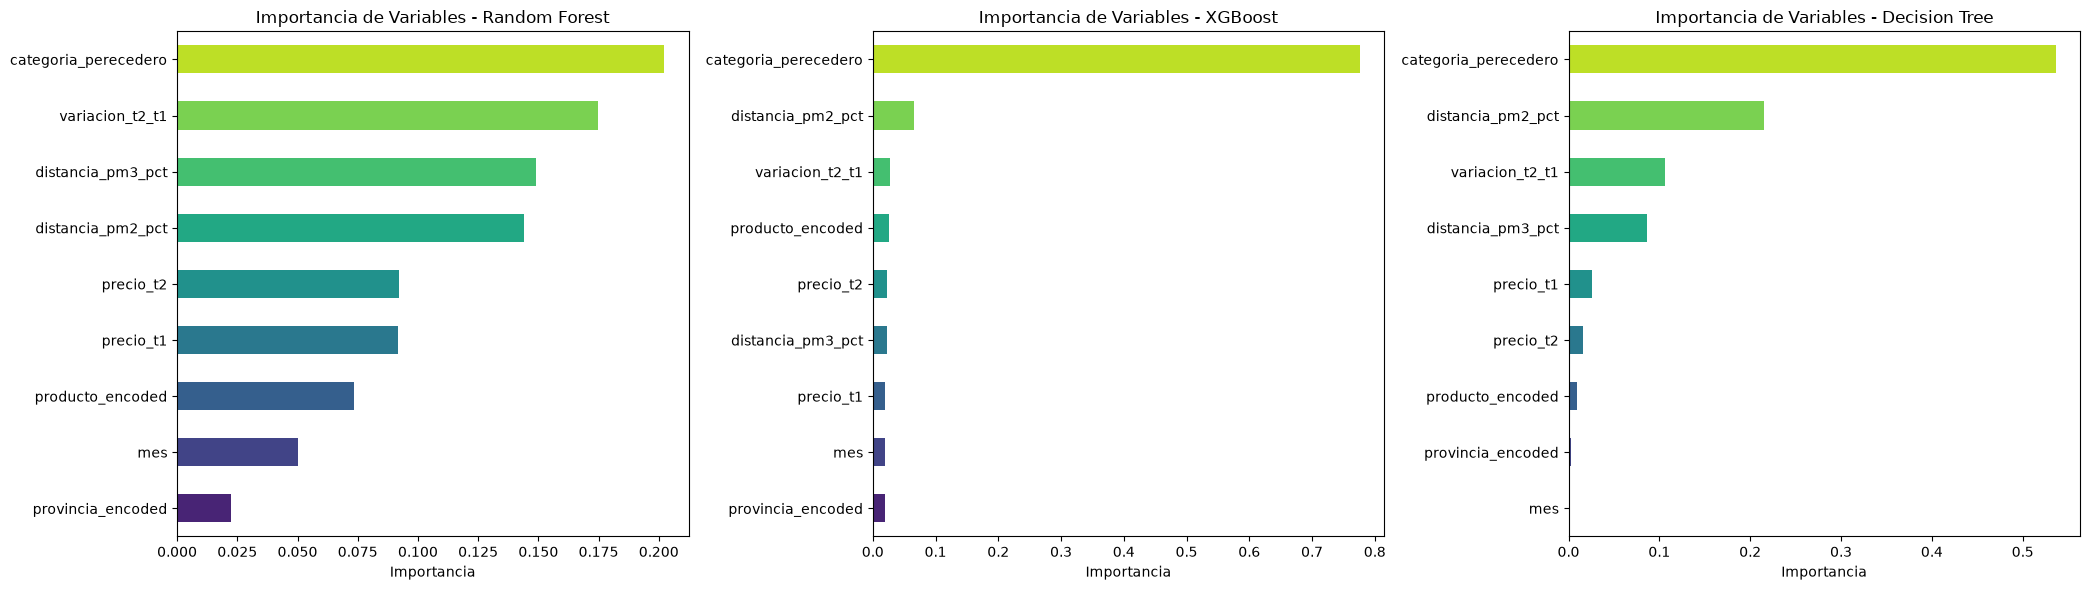

In [19]:
modelos_con_importancia = {k: v for k, v in resultados.items() if v['feature_importances'] is not None}
n_imp = len(modelos_con_importancia)
if n_imp > 0:
    fig, axes = plt.subplots(1, n_imp, figsize=(7 * n_imp, 6))
    axes = axes if n_imp > 1 else [axes]
    for idx, (nombre, res) in enumerate(modelos_con_importancia.items()):
        importancias = pd.Series(res['feature_importances'], index=FEATURES).sort_values(ascending=True)
        importancias.plot(kind='barh', ax=axes[idx], color=sns.color_palette('viridis', len(FEATURES)))
        axes[idx].set_title(f'Importancia de Variables - {nombre}')
        axes[idx].set_xlabel('Importancia')
    plt.tight_layout()
    plt.show()
else:
    print('Ningún modelo tiene feature_importances_ disponible.')

## Selección del modelo final

Criterios: F1-Score (Macro) >= 0.75 AND Accuracy >= 0.80. Si ambos cumplen, se selecciona el que tenga menor cantidad de falsos positivos/negativos.

In [20]:
candidatos = []
for nombre, res in resultados.items():
    f1 = res['metricas']['f1_macro']
    acc = res['metricas']['accuracy']
    cm = res['matriz_confusion']
    falsos = cm.sum() - np.trace(cm)  # falsos positivos + falsos negativos
    cumple = f1 >= 0.75 and acc >= 0.80
    candidatos.append({
        'Modelo': nombre,
        'F1-Score': f1,
        'Accuracy': acc,
        'Falsos (total)': falsos,
        'Cumple criterios': 'SI' if cumple else 'NO'
    })

df_candidatos = pd.DataFrame(candidatos)
print('=== MODELOS CANDIDATOS ===\n')
print(df_candidatos.to_string(index=False))

# Seleccionar mejor modelo
candidatos_validos = [c for c in candidatos if c['Cumple criterios'] == 'SI']
if candidatos_validos:
    mejor = min(candidatos_validos, key=lambda x: x['Falsos (total)'])
    print(f'\n>> MODELO SELECCIONADO: {mejor["Modelo"]}')
    print(f'   F1-Score: {mejor["F1-Score"]:.4f} | Accuracy: {mejor["Accuracy"]:.4f} | Falsos: {mejor["Falsos (total)"]}')
else:
    # Si ninguno cumple, seleccionar el de mayor F1
    mejor = max(candidatos, key=lambda x: x['F1-Score'])
    print(f'\n>> NINGUNO CUMPLE LOS CRITERIOS. Mejor por F1-Score: {mejor["Modelo"]}')
    print(f'   F1-Score: {mejor["F1-Score"]:.4f} | Accuracy: {mejor["Accuracy"]:.4f}')

=== MODELOS CANDIDATOS ===

             Modelo  F1-Score  Accuracy  Falsos (total) Cumple criterios
      Random Forest  0.445074  0.476975            1573               NO
            XGBoost  0.409729  0.448187            1872               NO
      Decision Tree  0.463019  0.493956            1542               NO
Logistic Regression  0.409732  0.444363            1613               NO
                KNN  0.346435  0.397357            1824               NO
                SVM  0.373582  0.396233            2302               NO

>> NINGUNO CUMPLE LOS CRITERIOS. Mejor por F1-Score: Decision Tree
   F1-Score: 0.4630 | Accuracy: 0.4940


## Análisis cualitativo

In [21]:
# Análisis de la matriz de confusión del mejor modelo
mejor_nombre = mejor['Modelo']
cm_mejor = resultados[mejor_nombre]['matriz_confusion']
clases = le_target.classes_

print(f'=== ANÁLISIS DE MATRIZ DE CONFUSIÓN - {mejor_nombre} ===\n')
print('Matriz de confusión (último fold):\n')
cm_df = pd.DataFrame(cm_mejor, index=[f'Real: {c}' for c in clases], columns=[f'Pred: {c}' for c in clases])
print(cm_df.to_string())

# Diagonal = correctos
correctos = np.trace(cm_mejor)
total = cm_mejor.sum()
print(f'\nCorrectos: {correctos}/{total} ({correctos/total*100:.1f}%)')

# Errores más comunes
print('\nErrores más comunes:')
for i, real in enumerate(clases):
    for j, pred in enumerate(clases):
        if i != j and cm_mejor[i][j] > 0:
            print(f'  Real={real} -> Pred={pred}: {cm_mejor[i][j]} veces')

=== ANÁLISIS DE MATRIZ DE CONFUSIÓN - Decision Tree ===

Matriz de confusión (último fold):

               Pred: Alza  Pred: Caída  Pred: Estable
Real: Alza            428          273            136
Real: Caída           277          427            132
Real: Estable         392          332           1160

Correctos: 2015/3557 (56.6%)

Errores más comunes:
  Real=Alza -> Pred=Caída: 273 veces
  Real=Alza -> Pred=Estable: 136 veces
  Real=Caída -> Pred=Alza: 277 veces
  Real=Caída -> Pred=Estable: 132 veces
  Real=Estable -> Pred=Alza: 392 veces
  Real=Estable -> Pred=Caída: 332 veces


In [24]:
from lstm_utils import entrenar_lstm

periodos_unicos = sorted(df_limpio['periodo'].unique())  # ajusta si tu variable de periodos se llama distinto
resultado_lstm = entrenar_lstm(resultado_preproc['dataset_wide'], periodos_unicos)

Construyendo secuencias...
Secuencias generadas: 20650
Estable    11522
Alza        4619
Caída       4509
Name: count, dtype: int64

Train: 16520 secuencias | Test: 4130 secuencias

Entrenando LSTM...
Epoch 1/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2910 - loss: 1.0964 - val_accuracy: 0.3235 - val_loss: 1.1047
Epoch 2/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3277 - loss: 1.0897 - val_accuracy: 0.3194 - val_loss: 1.0836
Epoch 3/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3493 - loss: 1.0801 - val_accuracy: 0.3446 - val_loss: 1.0773
Epoch 4/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3524 - loss: 1.0708 - val_accuracy: 0.3436 - val_loss: 1.0467
Epoch 5/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3535 - loss: 1.0650 - val_accuracy: 0.3344 - val_loss: 1.0458
Epoch 6/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3603 - loss: 1.0610 - val_accuracy: 0.3782 - val_loss: 1.0237
Epoch 7/50
259/259 ━━━━━━━━━━━━

## Guardado del modelo y artefactos

In [22]:
os.makedirs('data/models', exist_ok=True)

# Mejor modelo entrenado
modelo_final = resultados[mejor['Modelo']]['modelo_entrenado']
joblib.dump(modelo_final, 'data/models/mejor_modelo.pkl')

# Encoders
joblib.dump(le_target, 'data/models/le_target.pkl')
joblib.dump(le_producto, 'data/models/le_producto.pkl')
joblib.dump(le_provincia, 'data/models/le_provincia.pkl')

# Lista de features (referencia)
joblib.dump(FEATURES, 'data/models/features.pkl')

print('Artefactos guardados en data/models/:')
for f in sorted(os.listdir('data/models/')):
    size = os.path.getsize(f'data/models/{f}')
    print(f'  {f} ({size:,} bytes)')

print(f'\nModelo: {mejor["Modelo"]}')
print(f'F1-Score: {mejor["F1-Score"]:.4f} | Accuracy: {mejor["Accuracy"]:.4f}')

NameError: name 'le_producto' is not defined